In [1]:
# --- Colab setup -------------------------------------------------------------
# Upload fyp_data.zip to Google Drive under MyDrive/fyp/ before running this.
# Runtime > Change runtime type > T4 GPU.
import os, zipfile, shutil, glob
from google.colab import drive
drive.mount('/content/drive')

# locate the fyp folder, tolerating a stray leading/trailing space in its name
import glob as _g
_c = [p for p in _g.glob('/content/drive/MyDrive/*')
      if os.path.isdir(p) and os.path.basename(p).strip().lower() == 'fyp']
if not _c:
    raise FileNotFoundError('No folder named fyp at the top level of My Drive. '
                            'Top level contains: ' + str(sorted(os.listdir('/content/drive/MyDrive'))))
DRIVE = _c[0]
print('using Drive folder:', repr(DRIVE))
ROOT  = '/content/fyp'
WORK  = ROOT + '/'
for d in ('processed', 'models', 'Dataset', 'plots'):
    os.makedirs(f'{ROOT}/{d}', exist_ok=True)

if not os.path.exists(f'{ROOT}/processed/master_all_cities.csv'):
    with zipfile.ZipFile(f'{DRIVE}/fyp_data.zip') as z:
        z.extractall(f'{ROOT}/_unzip')
    for p in glob.glob(f'{ROOT}/_unzip/**/*.csv', recursive=True):
        name = os.path.basename(p)
        dest = 'processed' if name == 'master_all_cities.csv' else 'Dataset'
        shutil.move(p, f'{ROOT}/{dest}/{name}')
    shutil.rmtree(f'{ROOT}/_unzip', ignore_errors=True)

DATA_DIR = f'{ROOT}/Dataset'
print('city files:', sorted(os.listdir(DATA_DIR)))
print('master    :', round(os.path.getsize(f'{ROOT}/processed/master_all_cities.csv') / 1e6, 1), 'MB')

# The Kaggle notebooks called this to hunt for the data; here it is already known.
def find_csv_dir(root=None):
    return DATA_DIR

import torch
print('torch', torch.__version__, '| cuda:', torch.cuda.is_available(),
      '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')


Mounted at /content/drive
using Drive folder: '/content/drive/MyDrive/fyp'
city files: ['jena_germany_2000_2009_hourly.csv', 'london_uk_2000_2009_hourly.csv', 'newyork_usa_2000_2009_hourly.csv', 'sydney_australia_2000_2009_hourly.csv', 'tokyo_japan_2000_2009_hourly.csv']
master    : 162.1 MB
torch 2.11.0+cu128 | cuda: True | Tesla T4


> **Note on this notebook**
>
> **Where this ran:** Google Colab, on a T4 GPU. Six LSTM trainings (one pooled, five
> per-city) is far too slow on CPU. The outputs below are from that run.
>
> **Status:** this is the earlier design of the RQ2 experiment. It was later re-run
> locally as `11_per_city_vs_pooled_local.ipynb` with a denser sampling stride, and
> the figures reported in the dissertation come from that local run. This notebook is
> kept because it is an independent check on the same question: it uses a different
> sampling scheme and a different training budget, and reaches the same conclusion.
>
> **What it produced:** pooled 1.2677 C against a per-city mean of 1.2720 C, a gap of
> 0.004 C. The local run gives 1.2724 against 1.2880, a gap of 0.016 C. Both are far
> below any difference that would matter operationally, which is the finding reported.
>
> **Where to verify:** processed/rq2_summary.csv and processed/rq2_per_city_vs_pooled.csv.

# Notebook 11 - Per-city vs Pooled LSTM (RQ2)

Kaggle/GPU version. Tried this locally first but CPU was way too slow (about 4 min per epoch per city, 6 models), so moving it here.

Research question: do city-specific LSTM models beat a single pooled model trained on all 5 cities?

Plan:
- pooled LSTM on all cities together, with city one-hot so it knows which city
- one separate LSTM per city
- compare test MAE per city and overall

Same data prep + 168h lookback as the TFT notebook so the comparison is fair.

TODO: if pooled wins maybe note it's because more data, if per-city wins note the city-specific seasonality

In [2]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)
print('torch:', torch.__version__)

WORK = f'{ROOT}/'
os.makedirs(WORK + 'models', exist_ok=True)
os.makedirs(WORK + 'processed', exist_ok=True)
os.makedirs(WORK + 'plots', exist_ok=True)

device: cuda
torch: 2.11.0+cu128


## Load raw city CSVs and rebuild master
Same prep as the TFT notebook (notebook 10)

In [3]:
def find_csv_dir(root=None):
    return DATA_DIR

DATA_DIR = find_csv_dir()
print('found data at:', DATA_DIR)

found data at: /content/fyp/Dataset


In [5]:
DATA_DIR = '/content/fyp/Dataset/'
def find_csv_dir(root=None):
    return DATA_DIR
print(DATA_DIR)

/content/fyp/Dataset/


In [6]:
city_meta = {
    'jena_germany_2000_2009_hourly.csv':    ('Jena',     50.9227, 11.5865),
    'london_uk_2000_2009_hourly.csv':       ('London',   51.5074, -0.1278),
    'newyork_usa_2000_2009_hourly.csv':     ('New York', 40.7128, -74.0060),
    'sydney_australia_2000_2009_hourly.csv':('Sydney',  -33.8688, 151.2093),
    'tokyo_japan_2000_2009_hourly.csv':     ('Tokyo',    35.6762, 139.6503),
}

rename_map = {
    'temperature_2m': 'temperature',
    'relative_humidity_2m': 'humidity',
    'dew_point_2m': 'dew_point',
    'precipitation': 'precipitation',
    'rain': 'rain',
    'wind_speed_10m': 'wind_speed',
    'wind_direction_10m': 'wind_direction',
    'wind_gusts_10m': 'wind_gusts',
    'pressure_msl': 'pressure_msl',
    'surface_pressure': 'surface_pressure',
    'cloud_cover': 'cloud_cover',
    'cloud_cover_low': 'cloud_cover_low',
    'cloud_cover_mid': 'cloud_cover_mid',
    'cloud_cover_high': 'cloud_cover_high',
    'shortwave_radiation': 'shortwave_radiation',
    'direct_radiation': 'direct_radiation',
    'vapour_pressure_deficit': 'vapour_pressure_deficit',
    'wet_bulb_temperature_2m': 'wet_bulb_temp',
    'total_column_integrated_water_vapour': 'water_vapour',
    'soil_temperature_0_to_7cm': 'soil_temperature',
    'et0_fao_evapotranspiration': 'evapotranspiration',
}

def clean_col(c):
    c = re.sub(r'\s*\([^)]*\)', '', c)
    return c.strip()

all_dfs = []
for fname, (city, lat, lon) in city_meta.items():
    fp = DATA_DIR + fname
    d = pd.read_csv(fp, skiprows=3, parse_dates=['time'])
    d.columns = [clean_col(c) for c in d.columns]
    d = d.loc[:, ~d.columns.str.contains(r'\.')]
    d = d.loc[:, ~d.columns.duplicated()]
    d = d.rename(columns=rename_map)
    keep = ['time'] + [c for c in rename_map.values() if c in d.columns]
    d = d[keep]
    d['city'] = city
    d['lat'] = lat
    d['lon'] = lon
    all_dfs.append(d)
    print(city, d.shape)

master = pd.concat(all_dfs, ignore_index=True)
print('total rows:', len(master))

Jena (87672, 25)
London (87672, 25)
New York (87672, 25)
Sydney (87672, 25)
Tokyo (87672, 25)
total rows: 438360


In [7]:
# feature engineering - cyclical time + wind components (same as nb 10)
df = master.sort_values(['city', 'time']).reset_index(drop=True)

df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month
df['dayofyear'] = df['time'].dt.dayofyear

df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)
df['dayofyear_sin'] = np.sin(2*np.pi*df['dayofyear']/365)
df['dayofyear_cos'] = np.cos(2*np.pi*df['dayofyear']/365)

theta = np.deg2rad(df['wind_direction'])
df['wind_u'] = -df['wind_speed'] * np.sin(theta)
df['wind_v'] = -df['wind_speed'] * np.cos(theta)

# ffill/bfill per city then zero fill
for col in df.columns:
    if col in ['time', 'city', 'lat', 'lon']:
        continue
    if df[col].dtype == 'O':
        continue
    df[col] = df.groupby('city')[col].transform(lambda x: x.ffill().bfill())
    df[col] = df[col].fillna(0)

print('shape after FE:', df.shape)
print('NaN remaining:', df.isna().sum().sum())

shape after FE: (438360, 36)
NaN remaining: 0


In [8]:
FEATURE_COLS = [
    'temperature', 'humidity', 'dew_point',
    'precipitation', 'wind_speed', 'wind_gusts',
    'wind_u', 'wind_v',
    'pressure_msl', 'surface_pressure',
    'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
    'shortwave_radiation', 'direct_radiation',
    'vapour_pressure_deficit', 'wet_bulb_temp',
    'water_vapour', 'soil_temperature',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'dayofyear_sin', 'dayofyear_cos',
]

TARGET_COL = 'temperature'
TARGET_IDX = FEATURE_COLS.index(TARGET_COL)
SEQ_LEN    = 168
PRED_STEPS = 24

HIDDEN  = 128
LAYERS  = 2
DROPOUT = 0.2
BATCH   = 128
EPOCHS  = 25
PATIENCE = 5
LR = 1e-3

CITIES = ['Jena', 'London', 'New York', 'Sydney', 'Tokyo']
print('features:', len(FEATURE_COLS))
# make sure they all exist
missing = [c for c in FEATURE_COLS if c not in df.columns]
print('missing feature cols:', missing)

features: 26
missing feature cols: []


## Dataset + model + train/eval helpers

In [9]:
class WeatherDataset(Dataset):
    def __init__(self, data, seq_len, pred_steps, target_idx):
        self.data = torch.FloatTensor(data)
        self.seq_len = seq_len
        self.pred_steps = pred_steps
        self.target_idx = target_idx

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_steps + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_steps, self.target_idx]
        return x, y


class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden=128, layers=2, steps=24, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, layers, batch_first=True, dropout=dropout)
        self.norm = nn.LayerNorm(hidden)
        self.head = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, steps)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.norm(out[:, -1])
        return self.head(out)

In [10]:
def train_one_model(train_arr, val_arr, n_features, model_path):
    scaler = StandardScaler()
    tr = scaler.fit_transform(train_arr)
    vl = scaler.transform(val_arr)

    tr_dl = DataLoader(WeatherDataset(tr, SEQ_LEN, PRED_STEPS, TARGET_IDX),
                       batch_size=BATCH, shuffle=True, drop_last=True)
    vl_dl = DataLoader(WeatherDataset(vl, SEQ_LEN, PRED_STEPS, TARGET_IDX),
                       batch_size=BATCH, shuffle=False)

    model = LSTMForecaster(n_features, HIDDEN, LAYERS, PRED_STEPS, DROPOUT).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    loss_fn = nn.HuberLoss()

    best_val, pat = float('inf'), 0
    tr_hist, vl_hist = [], []

    for ep in range(1, EPOCHS + 1):
        model.train(); tl = 0
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tl += loss.item()
        tl /= len(tr_dl)

        model.eval(); vl_loss = 0
        with torch.no_grad():
            for xb, yb in vl_dl:
                vl_loss += loss_fn(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
        vl_loss /= len(vl_dl)

        tr_hist.append(tl); vl_hist.append(vl_loss)
        sched.step(vl_loss)

        if vl_loss < best_val:
            best_val, pat = vl_loss, 0
            torch.save(model.state_dict(), model_path)
        else:
            pat += 1
        if ep % 5 == 0 or ep == 1:
            print(f'  ep {ep:02d} | train {tl:.4f} | val {vl_loss:.4f}')
        if pat >= PATIENCE:
            print(f'  early stop at ep {ep}')
            break

    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    return model, scaler, tr_hist, vl_hist


def evaluate(model, scaler, test_arr):
    ts = scaler.transform(test_arr)
    dl = DataLoader(WeatherDataset(ts, SEQ_LEN, PRED_STEPS, TARGET_IDX),
                    batch_size=BATCH, shuffle=False)
    model.eval(); preds, acts = [], []
    with torch.no_grad():
        for xb, yb in dl:
            preds.append(model(xb.to(DEVICE)).cpu().numpy())
            acts.append(yb.numpy())
    p = np.concatenate(preds); a = np.concatenate(acts)
    tm, tsd = scaler.mean_[TARGET_IDX], scaler.scale_[TARGET_IDX]
    return p * tsd + tm, a * tsd + tm

## Pooled model - all cities + city one-hot

In [11]:
city_dummies = pd.get_dummies(df['city'], prefix='city').astype(float)
CITY_COLS = city_dummies.columns.tolist()
POOLED_COLS = FEATURE_COLS + CITY_COLS
print('pooled feature count:', len(POOLED_COLS))

pooled = pd.concat([df[FEATURE_COLS].reset_index(drop=True),
                    city_dummies.reset_index(drop=True)], axis=1)

# split each city chronologically then stack, so train/val/test cover same periods
tr_parts, vl_parts, te_parts = [], [], []
for city in CITIES:
    mask = (df['city'] == city).values
    cdf = pooled[mask].reset_index(drop=True)
    n = len(cdf)
    t_end, v_end = int(n*0.70), int(n*0.85)
    tr_parts.append(cdf.iloc[:t_end].values)
    vl_parts.append(cdf.iloc[t_end:v_end].values)
    te_parts.append(cdf.iloc[v_end:].values)

pool_train = np.concatenate(tr_parts, axis=0)
pool_val   = np.concatenate(vl_parts, axis=0)
pool_test_by_city = te_parts
print('pooled train:', pool_train.shape, 'val:', pool_val.shape)

pooled feature count: 31
pooled train: (306850, 31) val: (65755, 31)


In [12]:
print('Training pooled model...')
pooled_model, pooled_scaler, pool_tr, pool_vl = train_one_model(
    pool_train, pool_val, len(POOLED_COLS), WORK + 'models/lstm_pooled.pth')
print('done')

Training pooled model...
  ep 01 | train 0.0383 | val 0.0230
  ep 05 | train 0.0248 | val 0.0238
  early stop at ep 8
done


In [13]:
pooled_results = {}
pp_all, pa_all = [], []
for city, te in zip(CITIES, pool_test_by_city):
    p, a = evaluate(pooled_model, pooled_scaler, te)
    pp_all.append(p.flatten()); pa_all.append(a.flatten())
    mae = mean_absolute_error(a.flatten(), p.flatten())
    rmse = np.sqrt(mean_squared_error(a.flatten(), p.flatten()))
    r2 = r2_score(a.flatten(), p.flatten())
    pooled_results[city] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    print(f'{city:10s}  MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}')

pool_overall_mae = mean_absolute_error(np.concatenate(pa_all), np.concatenate(pp_all))
print('\nPooled overall MAE:', round(pool_overall_mae, 4))

Jena        MAE=1.2984  RMSE=1.7518  R2=0.9515
London      MAE=1.1881  RMSE=1.5830  R2=0.9312
New York    MAE=1.5770  RMSE=2.1764  R2=0.9513
Sydney      MAE=1.1796  RMSE=1.6641  R2=0.8815
Tokyo       MAE=1.0957  RMSE=1.5020  R2=0.9647

Pooled overall MAE: 1.2677


## Per-city models

In [14]:
per_city_results = {}
per_city_losses  = {}

for city in CITIES:
    print(f'\n--- {city} ---')
    cdf = df[df['city'] == city][FEATURE_COLS].reset_index(drop=True)
    n = len(cdf)
    t_end, v_end = int(n*0.70), int(n*0.85)
    tr, vl, te = cdf.iloc[:t_end].values, cdf.iloc[t_end:v_end].values, cdf.iloc[v_end:].values
    print(f'  train {len(tr)}  val {len(vl)}  test {len(te)}')

    safe = city.lower().replace(' ', '_')
    model, scaler, trh, vlh = train_one_model(tr, vl, len(FEATURE_COLS),
                                              WORK + f'models/lstm_{safe}.pth')
    p, a = evaluate(model, scaler, te)
    mae = mean_absolute_error(a.flatten(), p.flatten())
    rmse = np.sqrt(mean_squared_error(a.flatten(), p.flatten()))
    r2 = r2_score(a.flatten(), p.flatten())
    per_city_results[city] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    per_city_losses[city] = (trh, vlh)
    print(f'  MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}')

pc_overall_mae = np.mean([per_city_results[c]['mae'] for c in CITIES])
print('\nPer-city average MAE:', round(pc_overall_mae, 4))


--- Jena ---
  train 61370  val 13151  test 13151
  ep 01 | train 0.0558 | val 0.0273
  ep 05 | train 0.0286 | val 0.0250
  early stop at ep 7
  MAE=1.3362  RMSE=1.8183  R2=0.9477

--- London ---
  train 61370  val 13151  test 13151
  ep 01 | train 0.0678 | val 0.0416
  ep 05 | train 0.0362 | val 0.0396
  early stop at ep 8
  MAE=1.2329  RMSE=1.6409  R2=0.9261

--- New York ---
  train 61370  val 13151  test 13151
  ep 01 | train 0.0534 | val 0.0275
  ep 05 | train 0.0261 | val 0.0271
  early stop at ep 8
  MAE=1.5654  RMSE=2.1443  R2=0.9527

--- Sydney ---
  train 61370  val 13151  test 13151
  ep 01 | train 0.0815 | val 0.0416
  ep 05 | train 0.0447 | val 0.0418
  early stop at ep 7
  MAE=1.1339  RMSE=1.6183  R2=0.8880

--- Tokyo ---
  train 61370  val 13151  test 13151
  ep 01 | train 0.0463 | val 0.0176
  ep 05 | train 0.0226 | val 0.0169
  early stop at ep 9
  MAE=1.0917  RMSE=1.4736  R2=0.9660

Per-city average MAE: 1.272


## Comparison

In [15]:
rows = []
for city in CITIES:
    rows.append({
        'city': city,
        'pooled_mae':   round(pooled_results[city]['mae'], 4),
        'per_city_mae': round(per_city_results[city]['mae'], 4),
        'pooled_r2':    round(pooled_results[city]['r2'], 4),
        'per_city_r2':  round(per_city_results[city]['r2'], 4),
    })
comp = pd.DataFrame(rows)
comp['winner'] = comp.apply(lambda r: 'per-city' if r['per_city_mae'] < r['pooled_mae'] else 'pooled', axis=1)
print(comp.to_string(index=False))
print()
print('pooled overall MAE:', round(pool_overall_mae, 4))
print('per-city mean MAE: ', round(pc_overall_mae, 4))

    city  pooled_mae  per_city_mae  pooled_r2  per_city_r2   winner
    Jena      1.2984        1.3362     0.9515       0.9477   pooled
  London      1.1881        1.2329     0.9312       0.9261   pooled
New York      1.5770        1.5654     0.9513       0.9527 per-city
  Sydney      1.1796        1.1339     0.8815       0.8880 per-city
   Tokyo      1.0957        1.0917     0.9647       0.9660 per-city

pooled overall MAE: 1.2677
per-city mean MAE:  1.272


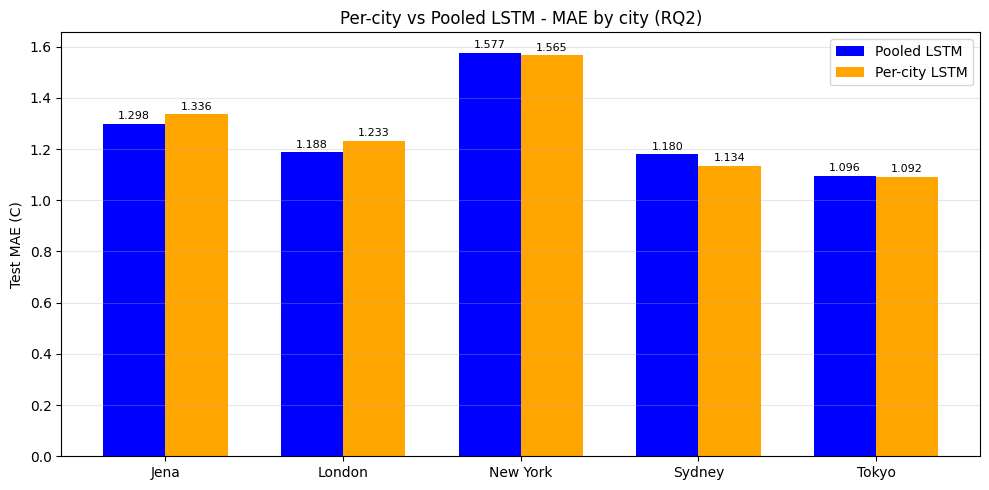

In [16]:
x = np.arange(len(CITIES)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, comp['pooled_mae'], width=w, color='blue', label='Pooled LSTM')
b2 = ax.bar(x + w/2, comp['per_city_mae'], width=w, color='orange', label='Per-city LSTM')
ax.set_xticks(x); ax.set_xticklabels(CITIES)
ax.set_ylabel('Test MAE (C)')
ax.set_title('Per-city vs Pooled LSTM - MAE by city (RQ2)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(WORK + 'plots/rq2_per_city_vs_pooled_mae.png', dpi=150)
plt.show()

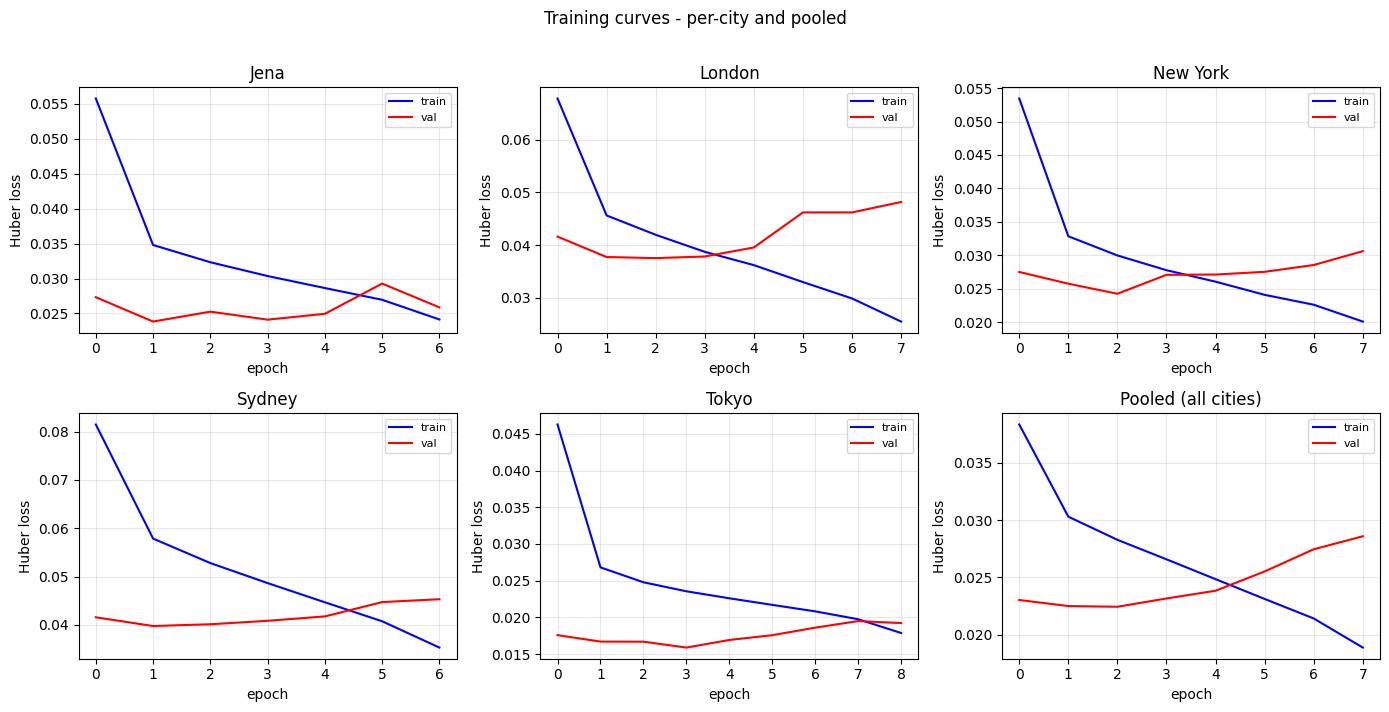

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7)); axes = axes.flatten()
for i, city in enumerate(CITIES):
    trh, vlh = per_city_losses[city]
    axes[i].plot(trh, label='train', color='blue')
    axes[i].plot(vlh, label='val', color='red')
    axes[i].set_title(city); axes[i].set_xlabel('epoch'); axes[i].set_ylabel('Huber loss')
    axes[i].legend(fontsize=8); axes[i].grid(alpha=0.3)
axes[5].plot(pool_tr, label='train', color='blue')
axes[5].plot(pool_vl, label='val', color='red')
axes[5].set_title('Pooled (all cities)'); axes[5].set_xlabel('epoch'); axes[5].set_ylabel('Huber loss')
axes[5].legend(fontsize=8); axes[5].grid(alpha=0.3)
plt.suptitle('Training curves - per-city and pooled', y=1.01)
plt.tight_layout()
plt.savefig(WORK + 'plots/rq2_training_curves.png', dpi=150)
plt.show()

In [18]:
comp.to_csv(WORK + 'processed/rq2_per_city_vs_pooled.csv', index=False)
summary = pd.DataFrame([{
    'experiment': 'RQ2',
    'pooled_overall_mae': round(pool_overall_mae, 4),
    'per_city_mean_mae':  round(pc_overall_mae, 4),
    'winner': 'per-city' if pc_overall_mae < pool_overall_mae else 'pooled',
}])
summary.to_csv(WORK + 'processed/rq2_summary.csv', index=False)
print('saved to /content/fyp/processed/')
print(summary)

saved to /content/fyp/processed/
  experiment  pooled_overall_mae  per_city_mean_mae  winner
0        RQ2              1.2677              1.272  pooled


In [19]:
# --- copy results back to Drive so they survive the session -------------------
import shutil, os, glob
os.makedirs(f'{DRIVE}/results', exist_ok=True)
saved = []
for pat in ('processed/*.csv', 'models/*.ckpt', 'models/*.pth', 'plots/*.png'):
    for p in glob.glob(f'{ROOT}/{pat}'):
        shutil.copy(p, f'{DRIVE}/results/{os.path.basename(p)}')
        saved.append(os.path.basename(p))
print('copied to Drive:', saved)


copied to Drive: ['rq2_summary.csv', 'master_all_cities.csv', 'rq2_per_city_vs_pooled.csv', 'lstm_london.pth', 'lstm_tokyo.pth', 'lstm_new_york.pth', 'lstm_pooled.pth', 'lstm_sydney.pth', 'lstm_jena.pth', 'rq2_per_city_vs_pooled_mae.png', 'rq2_training_curves.png']
